# Load the dataset

We will start by loading the dataset. For this project, I have chosen to use the Telco Customer Churn dataset. I will write a function to download the dataset so it can be used later if the dataset is updated

In [2]:
from pathlib import Path
import pandas as pd
import kagglehub

def load_churn_data():
    csv_path = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

    if not Path(csv_path).exists():
        kagglehub.dataset_download("blastchar/telco-customer-churn", output_dir="../data/")

    return pd.read_csv(csv_path)

churn_data = load_churn_data()

# Observe the data

Now that we have the dataset, we want to get an idea of what the data actually looks like so we can start planning what steps we will take to actually build our model

In [3]:
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
churn_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
churn_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
churn_data["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

From the inital inspection, we can observe that the dataset contains a lot of categorical and binary features that will require encoding before modeling. There are no missing values, so missing value handling is not currently necessary. The target variable, **Churn**, is imbalanced, with a much smaller proportion of customers who have churned compared to those who haven't. This imbalance will need to be considered during model training and evaluation.

# Split the data into training and testing sets

Now that we have made some baseline observations about the dataset, we want to split our dataset now. This will allow our test set to remain completely unseen so that our evaluation of our model is unbiased. Since we know that the distribution of our target feature, **Churn**, is imbalanced, I will use a stratified split so that the proportion of churn vs. non churn is preserved in the training and testing sets. I will use the common 80/20 to split the data 80% for training and 20% for testing

In [7]:
from sklearn.model_selection import train_test_split

X = churn_data.drop("Churn", axis=1)
y = churn_data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Categorical Feature Analysis

Now that we have our data split, we can make a copy of our training data to perform some more in depth EDA. We can start by looking at the categorical variables and observe things such as frequency counts, churn rates by category, and some histograms

In [8]:
churn_data = X_train.copy()
churn_data["Churn"] = y_train.copy()

categorical_cols = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]

for col in categorical_cols:
    print(f"Value proportion for {col}:")
    print(churn_data[col].value_counts(normalize=True))
    print("\n")


Value proportion for gender:
gender
Male      0.50284
Female    0.49716
Name: proportion, dtype: float64


Value proportion for Partner:
Partner
No     0.515619
Yes    0.484381
Name: proportion, dtype: float64


Value proportion for Dependents:
Dependents
No     0.701988
Yes    0.298012
Name: proportion, dtype: float64


Value proportion for PhoneService:
PhoneService
Yes    0.900781
No     0.099219
Name: proportion, dtype: float64


Value proportion for MultipleLines:
MultipleLines
No                  0.476571
Yes                 0.424210
No phone service    0.099219
Name: proportion, dtype: float64


Value proportion for InternetService:
InternetService
Fiber optic    0.440717
DSL            0.343805
No             0.215477
Name: proportion, dtype: float64


Value proportion for OnlineSecurity:
OnlineSecurity
No                     0.496450
Yes                    0.288072
No internet service    0.215477
Name: proportion, dtype: float64


Value proportion for OnlineBackup:
OnlineBacku

We can observe that the *Dependents* and *PhoneService* are imbalanced. For example most customers do not have dependents and most have phone service. This imbalance is important because categories with very few observations may have limited predictive power or could be combined with other categories during feature engineering. This imbalance could also influence model performance which we will need to consider when encoding or selecting features

In [9]:
for col in categorical_cols:
    churn_rate = churn_data.groupby(col)["Churn"].value_counts(normalize=True).unstack()
    print(f"Churn rate by {col}:")
    print(churn_rate)
    print("\n")

Churn rate by gender:
Churn         No       Yes
gender                    
Female  0.733667  0.266333
Male    0.735616  0.264384


Churn rate by Partner:
Churn          No       Yes
Partner                    
No       0.672289  0.327711
Yes      0.801026  0.198974


Churn rate by Dependents:
Churn             No       Yes
Dependents                    
No          0.686473  0.313527
Yes         0.848124  0.151876


Churn rate by PhoneService:
Churn               No       Yes
PhoneService                    
No            0.758497  0.241503
Yes           0.732020  0.267980


Churn rate by MultipleLines:
Churn                   No       Yes
MultipleLines                       
No                0.749721  0.250279
No phone service  0.758497  0.241503
Yes               0.712134  0.287866


Churn rate by InternetService:
Churn                  No       Yes
InternetService                    
DSL              0.813113  0.186887
Fiber optic      0.579138  0.420862
No               0.927512 

In the result above we want to look at features where the churn differs a lot across categories as this indicates that they could have strong predictive potential. These features are *Gender*, *PhoneService*, *MultipleLines*, *InternetService*, *PaperlessBilling*, and *PaymentMethod*. The differences suggest that these features could be useful predictors in our model

# Numeric Feature Analysis

Now that we have looked at the categorical variables to see what kind of transformations we might need to do and what features might be useful in predicting churn, we can turn out attention to the numeric variables. We first need to convert the total charges column to be numeric.

In [10]:
churn_data["TotalCharges"] = pd.to_numeric(churn_data["TotalCharges"], errors="coerce")


numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_cols:
    print(f"Distribution of {col}:")
    print(churn_data[col].describe())
    print("\n")

Distribution of tenure:
count    5634.000000
mean       32.485091
std        24.568744
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


Distribution of MonthlyCharges:
count    5634.000000
mean       64.929961
std        30.138105
min        18.400000
25%        35.662500
50%        70.500000
75%        90.000000
max       118.750000
Name: MonthlyCharges, dtype: float64


Distribution of TotalCharges:
count    5626.000000
mean     2302.604266
std      2279.173176
min        18.850000
25%       407.275000
50%      1398.125000
75%      3838.612500
max      8684.800000
Name: TotalCharges, dtype: float64




Looking at the output above, we can make a few observations. Let's first look at tenure

We can see that the tenure feature has a wide distribution of customer lifetimes, ranging from 0 to 72 months. The relatively low median indicates that a significant number of customers are still fairly new which could be important since newer customers are typically more likely to churn

Looking at MonthlyCharges we once again see a wide range of values indicating that customers are subscribed to a variety of different plans. The relatively high standard deviation suggests that there is a lot of variability in the pricing of the plans, which could influence churn behavior. Customers with higher monthly costs could be more likely to churn

Looking at TotalCharges we can see that the feature is heavily right skewed with a small portion of customers contributing disproportionately. This is to be expected though as total charges are accumulated over time and are therefore related to tenure. We can also see that there are some missing values, so if this feature is chosen to be a part of the later model, this will have to be addressed.

Since TotalCharges is likely highly correlated with tenure and MonthlyCharges, this could introduce some multicollinearity which should be considered when modeling.

We can now look at how these numeric features are related to churn

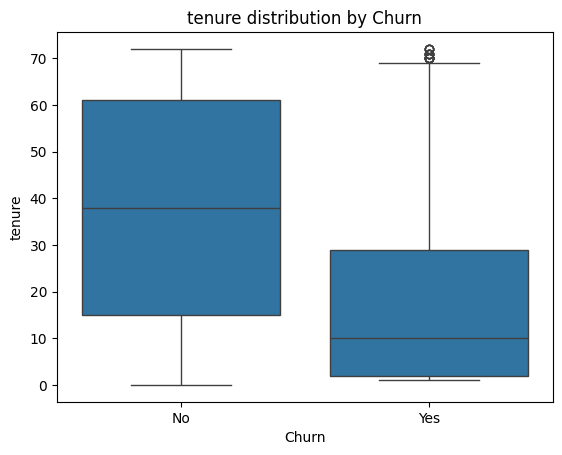

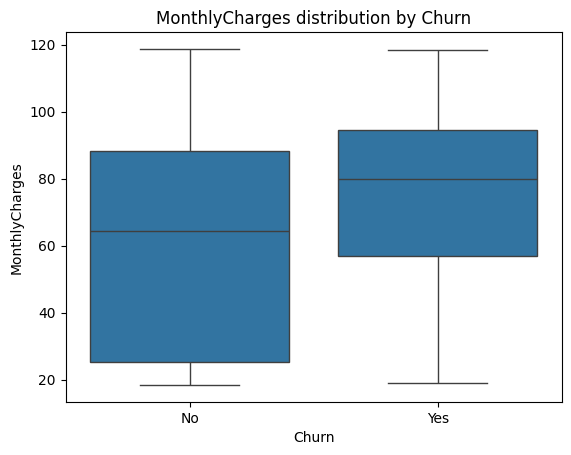

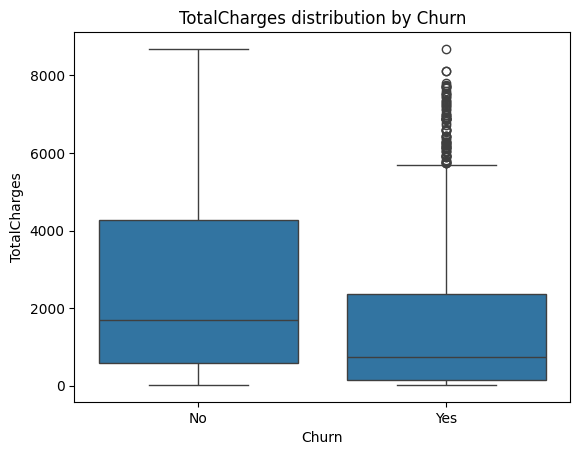

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    sns.boxplot(x='Churn', y=col, data=churn_data)
    plt.title(f"{col} distribution by Churn")
    plt.show()

Looking at the boxplots above we can make a few observations. Looking at the tenure plot, we can clearly see that the churners have much lower tenure on average which is to be expected. We can also see from the the MonthlyCharges plot that the churners have a slightly higher average monthly charge which could indicate that a higher monthly charge could lead to higher probability of churn. 

Next we can look at some overlay plots to hopefully gain some more insight

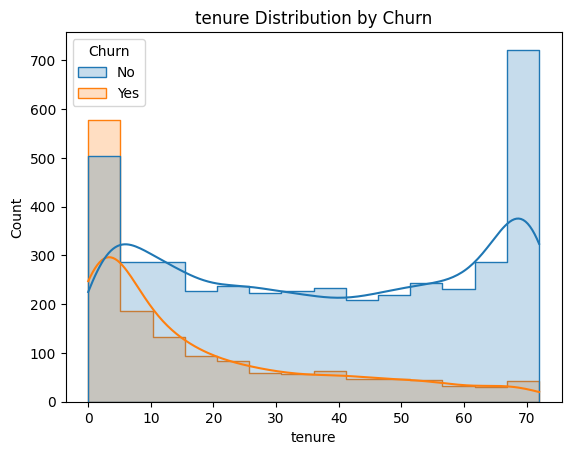

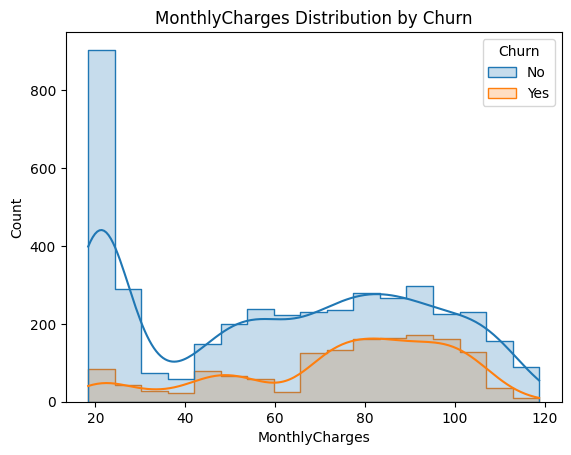

In [12]:
for col in ['tenure', 'MonthlyCharges']:
    sns.histplot(data=churn_data, x=col, hue='Churn', kde=True, element='step')
    plt.title(f'{col} Distribution by Churn')
    plt.show()

From the tenure plot, we can see that the majority of churn happens at low tenure (around 0-10 months). This suggests that most customers who churn do so early on in their lifecycle/subscription. We can also see that the churn drops off significantly after around 10-15 months and after the customers reach 30-50 months of tenure, churn is pretty rare. This is also supported by the blue churn region showing that the majority of customers with higher tenure tend to not churn.

From the MonthlyCharges plot, we can see that there is a higher risk of churn at higher price points. Between around $70 and $100, we can see the gap between the blue "No" region and the orange "Yes" region get smaller suggesting that customers paying higher monthly fees are more likely to churn when compared to those on lower cost plans. Another feature is the large spike in the blue distribution at $20-$25 showing that a large group of low cost plan customers have very low risk of churn.

Since we saw some signs earlier of a possible correlation between tenure and total charges, we will do a correlation analysis between the two features using a heatmap.

<Axes: >

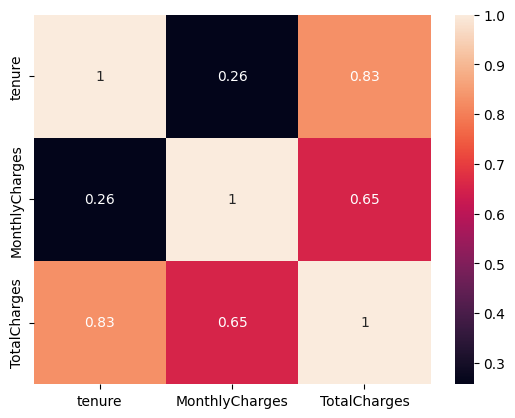

In [13]:
corr = churn_data[["tenure", "MonthlyCharges", "TotalCharges"]].corr()
sns.heatmap(corr, annot=True)

From this heatmap, we confirm that there is indeed a high correlation between tenure and TotalCharges. Based on the other EDA we have done and seeing that tenure seems to be a good predictor or churn, it would most likely be redundant to include TotalCharges in the model as well.

# Key Insights

From the analysis of the dataset, we have identified several important patterns that will be useful for predicting customer churn. The target variable is moderately imbalanced, with a smaller portion of customers having churned compared to those who remained, which will need to be taken into account during model evaluation. From the EDA, tenure emerges as one of the most informative features, with churn being much more common among customers with lower tenure. Monthly charges also show a noticeable relationship with churn, where customers with higher monthly charges tend to churn more frequently, indicating that pricing pressure may be a contributing factor.

In addition to the numeric features, several categorical variables show strong variation in churn rates across their categories. For example, contract type is fairly indicative of churn behavior, with month-to-month customers exhibiting significantly higher churn compared to those on longer-term contracts. Internet service type and payment method also display clear differences in churn likelihood. Overall, these findings suggest that a combination of customer tenure, pricing structure, service type, and contract terms play a key role in determining churn behavior.

Based on the findings from this EDA, the dataset will not prepared for modeling by handling categorical variables, ensuring proper data types, and structing the data for use in machine learning algorithms.

[Go to Preprocessing](02_preprocessing.ipynb)

In [14]:
X_train.to_parquet("../data/X_train.parquet", index=False)
X_test.to_parquet("../data/X_test.parquet", index=False)

y_train.to_frame().to_parquet("../data/y_train.parquet", index=False)
y_test.to_frame().to_parquet("../data/y_test.parquet", index=False)